<a href="https://colab.research.google.com/github/ichenjt/Machine-Learning/blob/main/HCC_AI_Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HCC 2025 ML Lab1 - Pokemon Recognition

* There are 4 classes of Pokémon.
* For each class, there are 20 images.

![](https://i.imgur.com/yuZeEPY.png)

## Environment Setup

In [14]:
!pip install gdown matplotlib scikit-learn > /dev/null

## Download Dataset

In [15]:
import os
if not os.path.exists("pokemon"):
    !gdown 19zDhGAb7hDNKHV80qwwcdQvGcqVeWjyh
    !unzip -q pokemon.zip

In [16]:
# Check the metadata of the image
!file pokemon/Charizard/01.png

pokemon/Charizard/01.png: PNG image data, 844 x 587, 8-bit/color RGBA, non-interlaced


## Import Package

Always make sure to import a package before using it, using the syntax `import xxx`. You can install these packages using the `pip` command, as demonstrated earlier.


In [17]:
import os
import glob

import matplotlib.pyplot as plot
import numpy as np
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from PIL import Image, ImageOps

## Utility Function

The following functions are used to display images. You can safely skip this section, but it"s recommended to take a quick look if you"re new to this!

In [18]:
POKEMON_RGB_PATH = "./pokemon"
POKEMON_GRAY_PATH = "./pokemon_processed"

def plot_gallery(images, titles, file_name, h, w, n_col=4):
    plot.clf()
    n_row = len(images) // n_col + (len(images) % n_col != 0)
    plot.figure(figsize=(1.8 * n_col, 2.4 * n_row))
    plot.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.35)
    for i in range(n_row * n_col):
        if i >= len(images):
            break
        plot.subplot(n_row, n_col, i + 1)
        plot.imshow(images[i].reshape((h, w)), cmap=plot.cm.gray)
        plot.title(titles[i], size=12)
        plot.xticks(())
        plot.yticks(())
    plot.savefig(file_name)


def show_results(y_test, y_pred, target_names):
    ac = accuracy_score(y_test, y_pred)
    pr = precision_score(y_test, y_pred, average="macro")
    rc = recall_score(y_test, y_pred, average="macro")
    print("\nEvaluate on test set:")
    print("  Accuracy : %.2f" % ac)
    print("  Precision: %.2f" % pr)
    print("  Recall   : %.2f" % rc)

    print("\nConfusion Matrix:")
    print("".join("%10s" % name for name in ([" "] + target_names)))
    for idx, arr in enumerate(confusion_matrix(y_test, y_pred)):
        print("%10s" % target_names[idx], end="")
        for v in arr:
            print("%10s" % str(v), end="")
        print("")
    print("")

## Checkpoint 1: Resizing Image

First, convert the image to grayscale and then resize it to the desired dimensions:

```python
img = Image.open(path)
img = img.convert("???")
img = img.resize("???")
```

In following package documents, you can find how to assign correct function arguments.
* [`Image.convert`](https://pillow.readthedocs.io/en/stable/reference/Image.html#PIL.Image.Image.convert)
    Convert all images to grayscale.
* [`Image.resize`](https://pillow.readthedocs.io/en/stable/reference/Image.html#PIL.Image.Image.resize)
    Resize all images to 200x200.


In [19]:
def get_pokemon(h, w):
    """
    Processing data. Resize pokemon images to size h * w and convert them to
    gray scale. For the convenience, save preprocessed images to the other
    folder.
    """
    os.makedirs(POKEMON_GRAY_PATH, exist_ok=True)
    pokemon_names, pokemon_paths = [], []

    for pokemon_name in sorted(os.listdir(POKEMON_RGB_PATH)):
        folder = os.path.join(POKEMON_RGB_PATH, pokemon_name)
        if not os.path.isdir(folder):
            continue

        # make new dir for the pokemon
        new_folder = os.path.join(POKEMON_GRAY_PATH, pokemon_name)
        os.makedirs(new_folder, exist_ok=True)

        # get path of images with file extension png
        paths_png = glob.glob(os.path.join(folder, "*.png"))
        paths_jpg = glob.glob(os.path.join(folder, "*.jpg"))
        paths = paths_png + paths_jpg
        # iterate over existing pokemon"s pictures and process each one
        for i, path in enumerate(sorted(paths)):
            img = Image.open(path)
            # TODO: Checkpoint 1.
            # - Convert `img` to grayscale.
            # - Resize `img` to h x w.
            ####
            img = img.convert("L") #灰階grayscale 是 mode "L"
            img = img.resize((w, h))
            new_path = os.path.join(
                POKEMON_GRAY_PATH, pokemon_name, "%d.jpg" % i)
            img.save(new_path)

    # read pokemon names and paths
    for pokemon_name in sorted(os.listdir(POKEMON_GRAY_PATH)):
        folder = os.path.join(POKEMON_GRAY_PATH, pokemon_name)
        if not os.path.isdir(folder):
            continue
        paths = [os.path.join(folder, f) for f in sorted(os.listdir(folder))]
        pokemon_names.extend([pokemon_name for _ in range(len(paths))])
        pokemon_paths.extend(paths)

    # convert string label to numerical value
    n_pokemon = len(pokemon_paths)
    target_names = list(np.unique(pokemon_names))
    target = np.searchsorted(target_names, pokemon_names)

    # read data
    pokemons = []
    for i, pokemon_path in enumerate(pokemon_paths):
        img = Image.open(pokemon_path)
        pokemon = np.asarray(img, dtype=np.float32)
        pokemons.append(pokemon)
    pokemons = np.array(pokemons)

    # shuffle pokemon
    indices = np.arange(n_pokemon)
    np.random.RandomState(42).shuffle(indices)
    pokemons, target = pokemons[indices], target[indices]
    pokemons = pokemons.reshape(len(pokemons), -1)

    return pokemons, target, target_names

In [20]:
# After finishing the above checkpoint, run this section and show the results
np.random.seed(1)
height, width = 200, 200
X, y, target_names = get_pokemon(height, width)

In [21]:
# Check the metadata of the image
!file pokemon_processed/Charizard/1.jpg

pokemon_processed/Charizard/1.jpg: JPEG image data, JFIF standard 1.01, aspect ratio, density 1x1, segment length 16, baseline, precision 8, 200x200, components 1


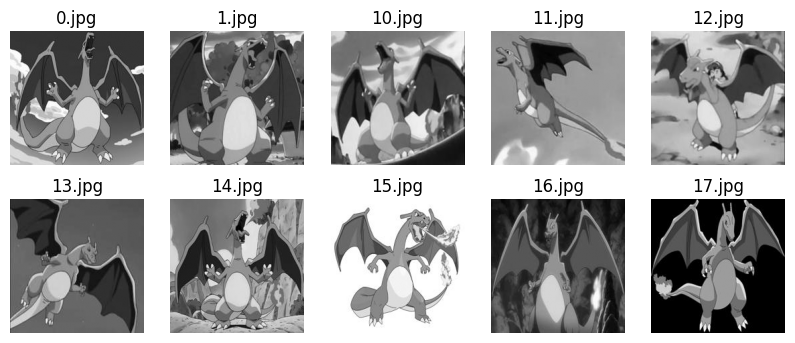

In [28]:
import os
from PIL import Image
import matplotlib.pyplot as plt

folder = "pokemon_processed/Charizard"
files = sorted(os.listdir(folder))[:10]

plt.figure(figsize=(10, 4))

for i, file in enumerate(files):
    img = Image.open(os.path.join(folder, file))
    plt.subplot(2, 5, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(file)
    plt.axis("off")

plt.show()

## Split the Dataset

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

## Checkpoint 2 - KNN Classifier

Document links: [`KNeighborsClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html#sklearn-neighbors-kneighborsclassifier), [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html#sklearn-model-selection-gridsearchcv).

In [35]:
# TODO: Checkpoint 2. Train a KNN classification model.
# - Extend "n_neighbors" to let GridSearchCV find the best value.
####
print("-" * 24 + " KNN " + "-" * 24)
param_grid = {
    "n_neighbors": [1,2,3,4,5,7,9], #K=1：看最像的1張圖 / K=3：看最像的3張圖 / K=5：看最像的5張圖
}

clf = GridSearchCV(KNeighborsClassifier(), param_grid, cv=3) #GridSearchCV():「自動測試參數」的工具 / KNeighborsClassifier():建立一個 KNN 分類器
clf = clf.fit(X_train, y_train) #把資料丟進去給模型學 -> X_train:訓練圖片資料(轉成數字) / Y_train:每張圖片的正確答案(Ex.Charizard,Gengar,Pikachu,Tangela)
print("Best params  : %s" % clf.best_params_)
print("Best accuracy: %.2f" % clf.best_score_)
y_pred = clf.predict(X_test)
show_results(y_test, y_pred, target_names)

------------------------ KNN ------------------------
Best params  : {'n_neighbors': 7}
Best accuracy: 0.73

Evaluate on test set:
  Accuracy : 0.60
  Precision: 0.68
  Recall   : 0.63

Confusion Matrix:
           Charizard    Gengar   Pikachu   Tangela
 Charizard         3         0         2         0
    Gengar         3         3         0         1
   Pikachu         0         0         4         0
   Tangela         2         0         0         2



## Checkpoint 3 - SVM

Documentation: [`SVC`](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html?highlight=svc#sklearn-svm-svc).

In [24]:
# TODO: Checkpoint 3. Train a SVM classification model.
# - Update `param_grid` to allow GridSearchCV to find the best parameters.
####
print("-" * 24 + " SVC " + "-" * 24) #SVM:找一條分界線，把不同寶可夢圖片分開
param_grid = {
    'kernel': ['rbf', 'linear'], #kernel:SVM 用來分資料的方法 (linear:用比較直的方式切資料 可以想成用一條線、一個平面去分開類別)(rbf:可以處理比較彎、比較複雜的分界線)
    'C': [0.1, 1, 10, 100], #模型對錯誤的容忍程度 (C 小：比較寬鬆，可以接受一些錯誤 / C 大：比較嚴格，想把訓練資料分得很準，但 C 太大可能會過度記住訓練資料，導致遇到新圖片反而表現不好)
    'gamma': [0.001, 0.01, 0.1, 1], #(gamma 小：影響範圍比較大，分界比較平滑 / gamma 大：影響範圍比較小，分界比較細、比較彎，但gamma 太大也可能會太貼合訓練資料，造成過度擬合)
}
clf = GridSearchCV(
    SVC(class_weight="balanced"), param_grid, cv=3)
clf = clf.fit(X_train, y_train)
print("Best params  : %s" % clf.best_params_)
print("Best accuracy: %.2f" % clf.best_score_)
y_pred = clf.predict(X_test)
show_results(y_test, y_pred, target_names)

------------------------ SVC ------------------------
Best params  : {'C': 0.1, 'gamma': 0.001, 'kernel': 'linear'}
Best accuracy: 0.85

Evaluate on test set:
  Accuracy : 1.00
  Precision: 1.00
  Recall   : 1.00

Confusion Matrix:
           Charizard    Gengar   Pikachu   Tangela
 Charizard         4         0         0         0
    Gengar         0         6         0         0
   Pikachu         0         0         6         0
   Tangela         0         0         0         4



## Checkpoint 4 - Dimension Reduction

You can find more information about the PCA method in the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html#sklearn-decomposition-pca).

Compute eigen vectors of train set.
Decompose the dataset by eigen vectors.


<Figure size 640x480 with 0 Axes>

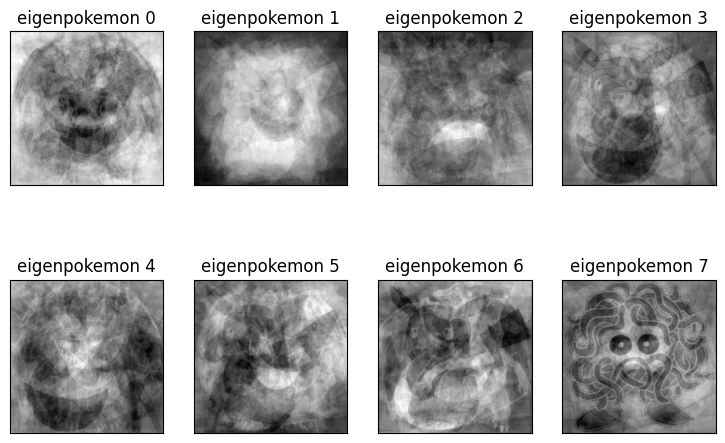

In [25]:
print("Compute eigen vectors of train set.")
n_components = 8
pca = PCA(n_components=n_components, whiten=True).fit(X_train)
print("Decompose the dataset by eigen vectors.")
X_train = pca.transform(X_train)
X_test = pca.transform(X_test)
eigenpokemons_titles = [
    "eigenpokemon %d" % i
    for i in range(pca.components_.shape[0])
]
plot_gallery(pca.components_, eigenpokemons_titles, "PCA", height, width)